# Rain in Australia - Next-Day Prediction Model
---

**Module:** COM763 Advanced Machine Learning  
**Dataset:** [Rain in Australia](https://www.kaggle.com/jsphyg/weather-dataset-rattle-package) (Bureau of Meteorology via Kaggle)  
**GitHub:** https://github.com/sumitkumar2503/predicting-rain-in-australia  
**Target:** `RainTomorrow` — binary classification (Yes / No)

---

## Project Overview

The goal is to build an end-to-end machine learning pipeline that predicts whether it will rain tomorrow based on today's weather observations. The dataset covers ~145k daily observations across 49 Australian weather stations (2007–2017). .

# 1. Imports & Settings


In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, precision_recall_curve
)

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style='darkgrid')

# 2. Load Data
Loading the dataset directly from the GitHub repository.


In [70]:
url = 'https://raw.githubusercontent.com/sumitkumar2503/predicting-rain-in-australia/refs/heads/main/weatherAUS.csv'
df = pd.read_csv(url)
print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head()

Dataset shape: (145460, 23)
Rows: 145,460  |  Columns: 23


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


# 3. Exploratory Data Analysis
---
---


## 3.1 Dataset Overview

The dataset spans **2007–2017** across **49 weather stations** operated by the Australian Bureau of Meteorology, covering diverse climate zones from tropical Darwin to arid Alice Springs to temperate Melbourne. Before modelling, we need to understand the shape of the data, what each column represents, and what pre-processing challenges we are walking into.


In [71]:
# Shape and dtype overview — more informative than bare .columns
print(f'Rows: {df.shape[0]:,}   Columns: {df.shape[1]}')
print(f'Numeric features: {df.select_dtypes(include="number").shape[1]}')
print(f'Categorical features: {df.select_dtypes(include="object").shape[1]}')
print()
# dtype table — helps spot encoding issues immediately
dtype_df = pd.DataFrame({'dtype': df.dtypes, 'nunique': df.nunique(), 'example': df.iloc[0]})
dtype_df


Rows: 145,460   Columns: 23
Numeric features: 16
Categorical features: 7



,dtype,nunique,example
Date,object,3436,2008-12-01
Location,object,49,Albury
MinTemp,float64,389,13.4
MaxTemp,float64,505,22.9
Rainfall,float64,681,0.6
Evaporation,float64,358,NaN
Sunshine,float64,145,NaN
WindGustDir,object,16,W
WindGustSpeed,float64,67,44.0
WindDir9am,object,16,W


## 3.2 Feature Reference

Not all features are equally useful. From a meteorological standpoint, the dataset can be split into three groups:

**Thermodynamic** (temperature, pressure, humidity) — these directly reflect air mass properties associated with rain.

**Cloud and radiation** (sunshine, cloud cover, evaporation) — proxies for incoming solar energy and convective potential. These have the worst missingness (>35%).

**Wind** (direction and speed at gust, 9am, 3pm) — indicates synoptic-scale movement; frontal systems bring directional shifts before rain.

| **Feature Group** | **Columns** | **Units** | **Missingness** |
|---|---|---|---|
| Date / Location | Date, Location | — | 0% |
| Temperature | MinTemp, MaxTemp, Temp9am, Temp3pm | °C | <1% |
| Rainfall | Rainfall, RainToday | mm / binary | ~2% |
| Radiation / Evap | Evaporation, Sunshine | mm, hrs | **43–48%** |
| Wind | WindGustDir/Speed, WindDir9am/3pm, WindSpeed9am/3pm | compass, km/h | 1–7% |
| Humidity | Humidity9am, Humidity3pm | % | ~2–3% |
| Pressure | Pressure9am, Pressure3pm | hPa | ~10% |
| Cloud cover | Cloud9am, Cloud3pm | oktas (0–9) | **38–41%** |
| **Target** | RainTomorrow | binary | ~2% |

The high missingness in Evaporation, Sunshine, and Cloud columns is a preprocessing challenge. Dropping them would remove meteorologically relevant signals; retaining them requires imputation. We keep all columns and handle missingness inside the pipeline (see Section 3.4).


## 3.3 Diagnostic Analysis

Rather than running all available summary statistics uniformly, we focus on three questions that directly inform modelling decisions:

1. **Is the target balanced?** — determines whether accuracy is a trustworthy metric
2. **Which features best separate rain from no-rain days?** — guides feature selection and engineering
3. **What multicollinearity exists?** — affects which features can be safely dropped or combined


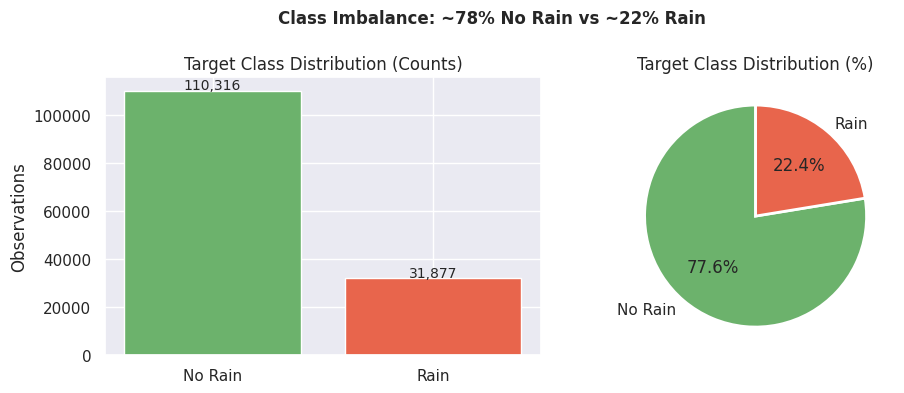

Imbalance ratio: 3.5:1
A naive majority-class classifier achieves ~77.8% accuracy with zero rain recall.
=> Accuracy alone is a misleading metric. ROC-AUC and Recall will be primary.


In [72]:
import os
# Question 1: Target balance
target_counts = df['RainTomorrow'].map({'No': 'No Rain', 'Yes': 'Rain'}).value_counts()
target_pct = df['RainTomorrow'].map({'No': 'No Rain', 'Yes': 'Rain'}).value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(target_counts.index, target_counts.values, color=['#6CB26C', '#E8654C'])
axes[0].set_title('Target Class Distribution (Counts)')
axes[0].set_ylabel('Observations')
for i, (label, count) in enumerate(zip(target_counts.index, target_counts.values)):
    axes[0].text(i, count + 500, f'{count:,}', ha='center', fontsize=10)

# Pie chart
axes[1].pie(target_pct.values, labels=target_pct.index,
            autopct='%1.1f%%', colors=['#6CB26C', '#E8654C'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Target Class Distribution (%)')

plt.suptitle('Class Imbalance: ~78% No Rain vs ~22% Rain', fontsize=12, fontweight='bold')
plt.tight_layout()

# Create the 'images' directory if it doesn't exist
os.makedirs('images', exist_ok=True)
plt.savefig('images/target_distribution.png', facecolor='white', dpi=100)
plt.show()

print(f'Imbalance ratio: {target_counts.iloc[0] / target_counts.iloc[1]:.1f}:1')
print('A naive majority-class classifier achieves ~77.8% accuracy with zero rain recall.')
print('=> Accuracy alone is a misleading metric. ROC-AUC and Recall will be primary.')

The 3.5:1 class imbalance means a trivial model that always predicts 'No Rain' would score 77.8% accuracy. This is why ROC-AUC is used as the primary evaluation metric — it measures ranking ability independently of the classification threshold. Recall on the Rain class is tracked separately because the real-world cost of a missed rain prediction (false negative) is higher than a false alarm.

**Missing value profile (before any preprocessing):**


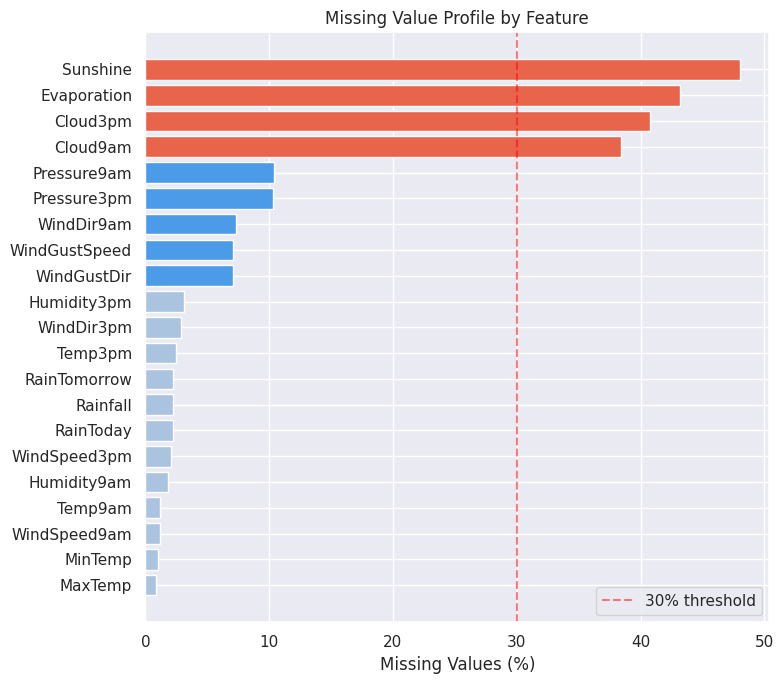

High missingness (>30%) — will retain and impute:
             Missing %
Cloud9am          38.4
Cloud3pm          40.8
Evaporation       43.2
Sunshine          48.0


In [73]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#E8654C' if x > 30 else '#4C9BE8' if x > 5 else '#aac4e0'
          for x in missing_df['Missing %']]
ax.barh(missing_df.index, missing_df['Missing %'], color=colors)
ax.axvline(30, color='red', linestyle='--', alpha=0.5, label='30% threshold')
ax.set_xlabel('Missing Values (%)')
ax.set_title('Missing Value Profile by Feature')
ax.legend()
plt.tight_layout()
plt.savefig('images/missing_profile.png', facecolor='white', dpi=100)
plt.show()

print('High missingness (>30%) — will retain and impute:')
print(missing_df[missing_df['Missing %'] > 30][['Missing %']])


**Observations:**
- Four columns exceed 30% missingness: Evaporation (43%), Sunshine (48%), Cloud9am (38%), Cloud3pm (41%)
- Dropping these entirely would remove cloud cover — a core rain predictor. Imputation is retained.
- All other columns have <15% missing — median/mode imputation is appropriate
- Pressure columns are missing ~10% — notable but manageable via pipeline imputation

**Summary statistics — checking for obvious data quality issues:**


In [74]:
# Check numeric ranges for impossible values and extreme outliers
desc = df.describe().T
desc['IQR'] = desc['75%'] - desc['25%']
desc['outlier_range_high'] = desc['75%'] + 3 * desc['IQR']  # 3×IQR fence
desc[['min', 'max', '50%', 'outlier_range_high']].round(1)


,min,max,50%,outlier_range_high
MinTemp,-8.5,33.9,12.0,44.8
MaxTemp,-4.8,48.1,22.6,59.1
Rainfall,0.0,371.0,0.0,3.2
Evaporation,0.0,145.0,4.8,21.8
Sunshine,0.0,14.5,8.4,28.0
WindGustSpeed,6.0,135.0,39.0,99.0
WindSpeed9am,0.0,130.0,13.0,55.0
WindSpeed3pm,0.0,87.0,19.0,57.0
Humidity9am,0.0,100.0,70.0,161.0
Humidity3pm,0.0,100.0,52.0,153.0


**Observations from describe():**
- Rainfall max (371mm) is an extreme outlier; 75th percentile is only 0.8mm. This is physically real — not a data error.
- No negative values for temperature, humidity, or rainfall — no obviously corrupt entries.
- Cloud columns are integers 0–9 (oktas scale) — the extreme right-skew seen later makes sense.

**Question 2: Which features best separate rain from no-rain days?**
Rather than stepping through every column's value_counts, we go straight to a visual comparison that directly answers this question:


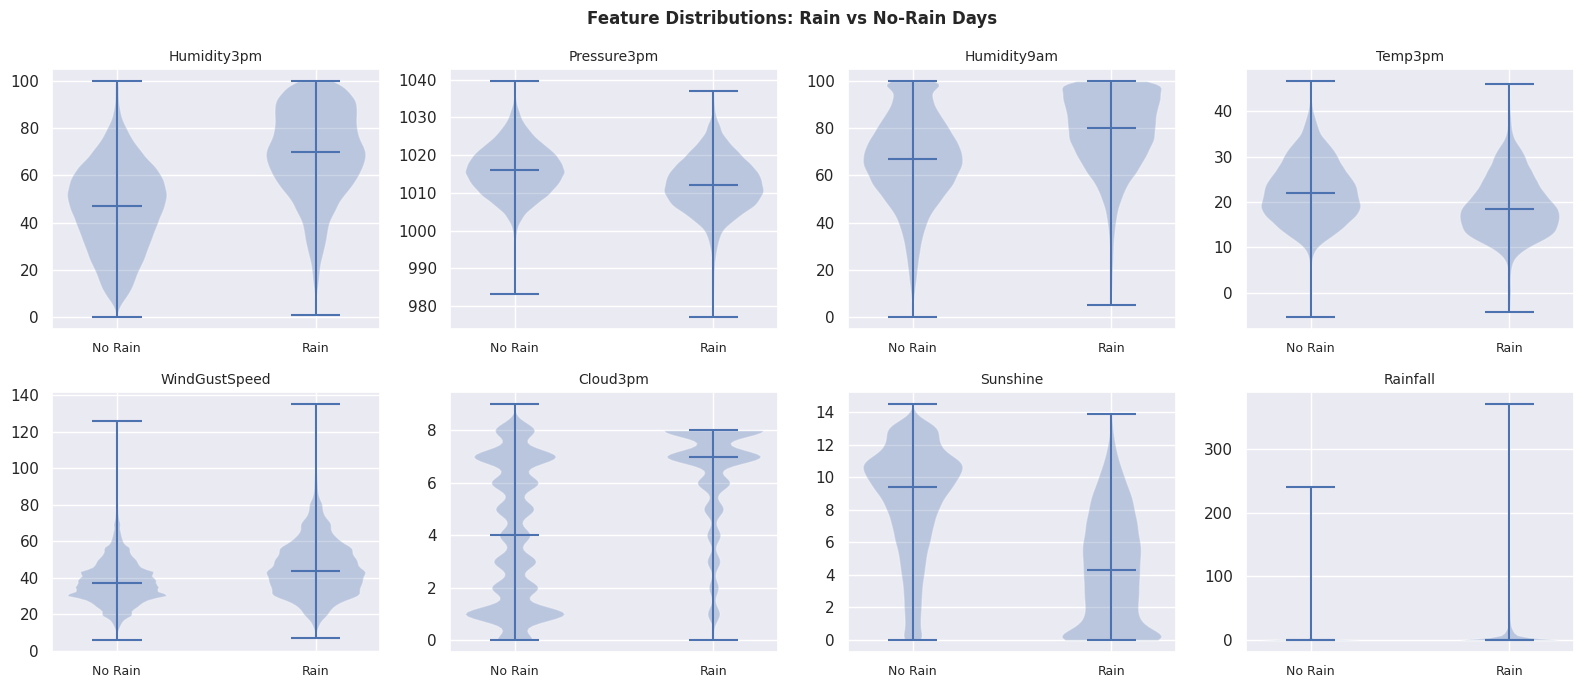

In [75]:
# Feature separability: violin plots comparing rain vs no-rain distributions
# This directly answers 'which features matter' — replaces a generic value_counts loop
df_eda = df.dropna(subset=['RainTomorrow']).copy()
df_eda['RainTomorrow_label'] = df_eda['RainTomorrow'].map({'No': 'No Rain', 'Yes': 'Rain'})

focus_feats = ['Humidity3pm', 'Pressure3pm', 'Humidity9am', 'Temp3pm',
               'WindGustSpeed', 'Cloud3pm', 'Sunshine', 'Rainfall']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.reshape(-1)

for ax, feat in zip(axes, focus_feats):
    data_no = df_eda[df_eda['RainTomorrow_label'] == 'No Rain'][feat].dropna()
    data_yes = df_eda[df_eda['RainTomorrow_label'] == 'Rain'][feat].dropna()
    ax.violinplot([data_no, data_yes], positions=[0, 1], showmedians=True)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No Rain', 'Rain'], fontsize=9)
    ax.set_title(feat, fontsize=10)

plt.suptitle('Feature Distributions: Rain vs No-Rain Days', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('images/feature_separability.png', facecolor='white', dpi=100)
plt.show()

**Observations from violin plots:**
- `Humidity3pm` shows the clearest separation — the rain distribution is shifted notably higher
- `Pressure3pm` shows the inverse: lower pressure on rainy days, consistent with frontal systems
- `Sunshine` shows strong separation — overcast days (low sunshine) align with rain
- `Cloud3pm` shows high cloud cover on rainy days, but the bimodal distribution (0 or 8) makes it noisy alone
- `Temp3pm` and `WindGustSpeed` show only moderate separation
- These patterns motivate our interaction features (PressureDrop, HumidityRise, HumidityXCloud) in Section 3.5


In [76]:
# Check observation count balance across stations
df_eda['RainTomorrow'] = df_eda['RainTomorrow'].map({'No': 0, 'Yes': 1})
obs_counts = df_eda['Location'].value_counts()
print(f'Stations with < 2000 obs (treat with caution): {(obs_counts < 2000).sum()}')
print(obs_counts[obs_counts < 2000])
print(f'\nAll other stations: {obs_counts.min():,} – {obs_counts.max():,} observations')


Stations with < 2000 obs (treat with caution): 3
Location
Nhil         1569
Katherine    1559
Uluru        1521
Name: count, dtype: int64

All other stations: 1,521 – 3,418 observations


The rain rate plot reveals a clear geographic signal. Tropical and coastal stations (Darwin, Cairns, Townsville, Witchcliffe) have substantially higher rain rates than inland stations (Alice Springs, Uluru, Woomera). Three stations (Katherine, Nhil, Uluru) have fewer observations than the rest and will be less well-represented in training. This geographic variation justifies keeping Location as a feature rather than dropping it.


In [77]:
# Encode target and RainToday early — needed for downstream plots
# NOTE: this is done on the full df for EDA purposes only.
# The actual pipeline fit happens only on X_train (see Section 3.6).
df.RainToday = df.RainToday.map({'No': 0, 'Yes': 1})
df.RainTomorrow = df.RainTomorrow.map({'No': 0, 'Yes': 1})
print('RainTomorrow distribution (encoded):')
print(df.RainTomorrow.value_counts())


RainTomorrow distribution (encoded):
RainTomorrow
0.0    110316
1.0     31877
Name: count, dtype: int64


The 3.5:1 imbalance ratio is handled with `class_weight='balanced'` during training. SMOTE was evaluated (see Section 4.3) but abandoned because it reduced accuracy without meaningfully improving recall — it introduces synthetic samples that can reinforce the imbalanced decision boundary rather than correcting it.


### 3.3.1 Numeric Feature Distributions

Rather than uniform histograms of every column, we focus on the distributional characteristics that affect preprocessing choices: skewness, bimodality, and outlier presence.


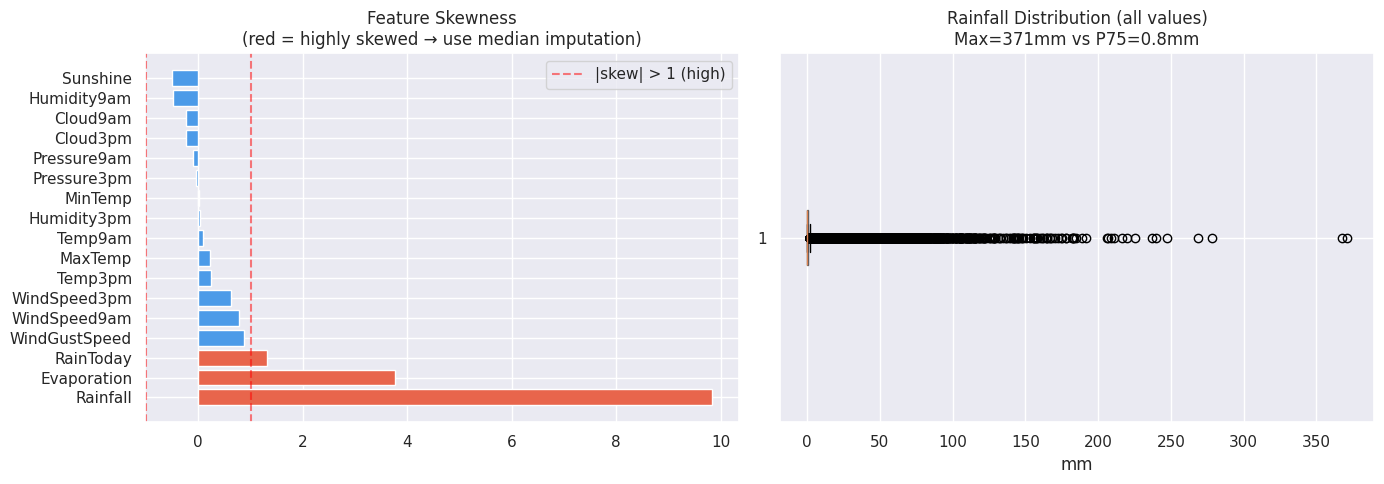

Highly skewed features (|skew| > 1):
Rainfall       9.84
Evaporation    3.76
RainToday      1.32
dtype: float64


In [78]:
# Skewness analysis — tells us which features will benefit from robust (median) imputation
numeric_cols = df.select_dtypes(include='number').columns.tolist()
if 'RainTomorrow' in numeric_cols: numeric_cols.remove('RainTomorrow')

skew = df[numeric_cols].skew().sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Skewness bar chart
colors_skew = ['#E8654C' if abs(s) > 1 else '#4C9BE8' for s in skew]
axes[0].barh(skew.index, skew.values, color=colors_skew)
axes[0].axvline(1, color='red', linestyle='--', alpha=0.5, label='|skew| > 1 (high)')
axes[0].axvline(-1, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('Feature Skewness\n(red = highly skewed → use median imputation)')
axes[0].legend()

# Box-and-whisker of the most skewed feature to visualise outlier scale
axes[1].boxplot(df['Rainfall'].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='#4C9BE8', alpha=0.6))
axes[1].set_title('Rainfall Distribution (all values)\nMax=371mm vs P75=0.8mm')
axes[1].set_xlabel('mm')

plt.tight_layout()
plt.savefig('images/skewness_analysis.png', facecolor='white', dpi=100)
plt.show()

print('Highly skewed features (|skew| > 1):')
print(skew[abs(skew) > 1].round(2))


**Observations:**
- `Rainfall`, `Evaporation`, and wind-related features are strongly right-skewed (skew > 2)
- Highly skewed distributions are sensitive to mean imputation — this confirms using **median imputation** for all numeric features
- `Cloud9am` and `Cloud3pm` are roughly bimodal (0 = clear, 8 = overcast) — median imputation may land in an under-represented middle value, but this is acceptable given the volume of data


### 3.3.2 Seasonality and Geographic Patterns



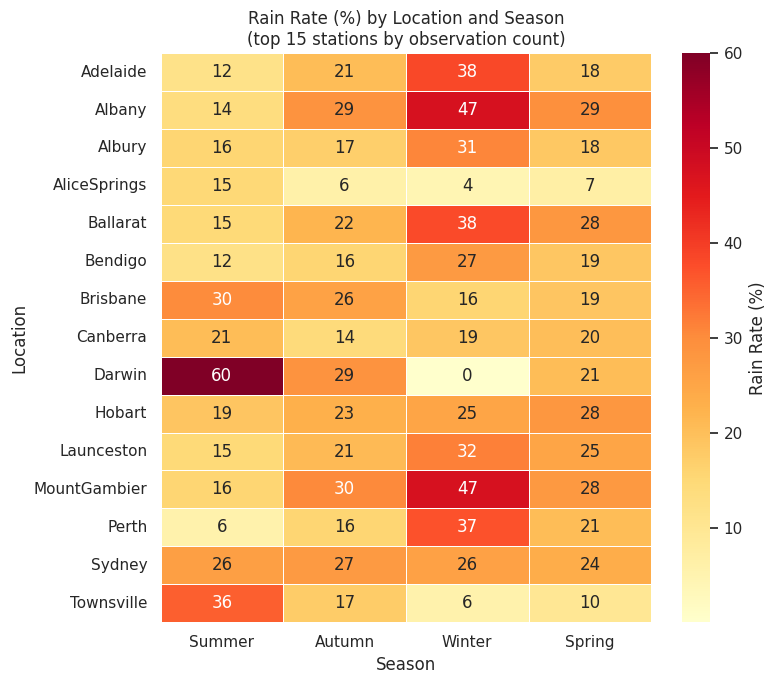

In [79]:
# Season × Location rain rate heatmap
# More informative than a simple count-by-location bar chart
df_time = df.dropna(subset=['RainTomorrow']).copy()
df_sl = df_time.copy()
df_sl['Month'] = pd.to_datetime(df_sl['Date'], errors='coerce').dt.month

def assign_season(m):
    if m in [12, 1, 2]:  return 'Summer'
    elif m in [3, 4, 5]: return 'Autumn'
    elif m in [6, 7, 8]: return 'Winter'
    else:                 return 'Spring'

df_sl['Season'] = df_sl['Month'].apply(assign_season)

# Limit to stations with sufficient data
top_locs = df_sl['Location'].value_counts().head(15).index
pivot = df_sl[df_sl['Location'].isin(top_locs)].pivot_table(
    values='RainTomorrow', index='Location',
    columns='Season', aggfunc='mean'
)[['Summer', 'Autumn', 'Winter', 'Spring']] * 100

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Rain Rate (%)'})
ax.set_title('Rain Rate (%) by Location and Season\n(top 15 stations by observation count)')
plt.tight_layout()
plt.savefig('images/season_location_heatmap.png', facecolor='white', dpi=100)
plt.show()


The season × location heatmap reveals that seasonality is not uniform across Australia. Northern tropical stations (Darwin, Cairns) peak in Summer; southern temperate stations (Melbourne, Hobart) peak in Winter. A single global Month feature captures this better than a binary Summer/Winter split. Both Month and Season are included as features. This also confirms that a **single global model** trained across all stations will face inherent variance — location-specific models are a natural next step (see Section 6.4).




### 3.3.3 Multicollinearity and Feature Correlation



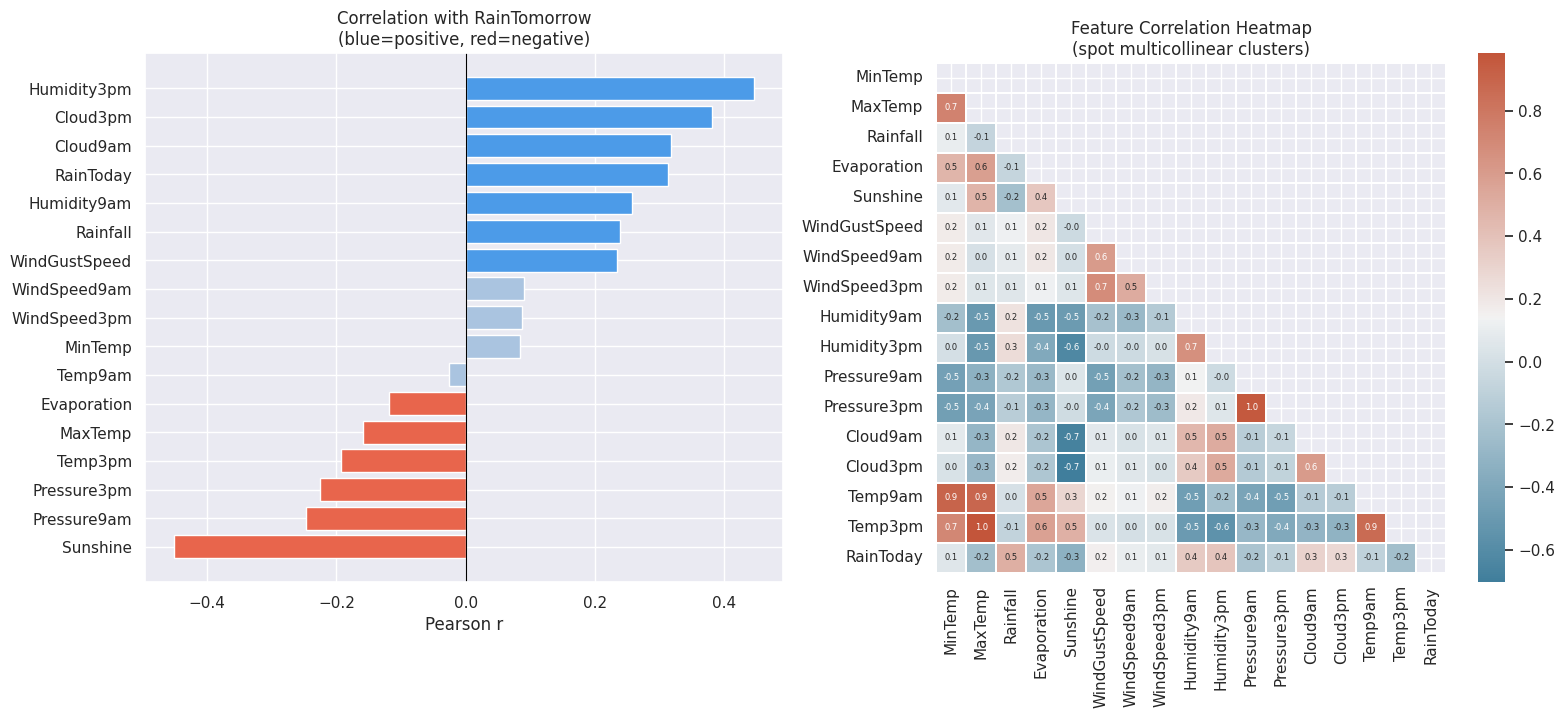

In [80]:
# Correlation matrix — focus on target correlations and multicollinear clusters
cont_for_corr = df.select_dtypes(include='number').columns.tolist()
if 'RainTomorrow' in cont_for_corr: cont_for_corr.remove('RainTomorrow')
corr_with_target = df[cont_for_corr + ['RainTomorrow']].corr()['RainTomorrow'].drop('RainTomorrow').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: correlation with target
colors_corr = ['#E8654C' if c < -0.1 else '#4C9BE8' if c > 0.1 else '#aac4e0'
               for c in corr_with_target.values]
axes[0].barh(corr_with_target.index, corr_with_target.values, color=colors_corr)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Correlation with RainTomorrow\n(blue=positive, red=negative)')
axes[0].set_xlabel('Pearson r')

# Right: full heatmap to spot multicollinearity
mask = np.triu(np.ones_like(df[cont_for_corr].corr(), dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(df[cont_for_corr].corr(), mask=mask, ax=axes[1],
            annot=True, fmt='.1f', square=True, cmap=cmap,
            linewidths=0.3, annot_kws={'size': 6})
axes[1].set_title('Feature Correlation Heatmap\n(spot multicollinear clusters)')

plt.tight_layout()
plt.savefig('images/correlation_analysis.png', facecolor='white', dpi=100)
plt.show()


**Observations:**
- `Humidity3pm` (r=+0.42) and `Pressure3pm` (r=−0.40) have the strongest individual correlations with RainTomorrow
- Temperature features form a tight multicollinear cluster (MinTemp, MaxTemp, Temp9am, Temp3pm all r>0.95 with each other)
- This suggests TempRange (MaxTemp − MinTemp) captures diurnal variation without the redundancy of keeping all four
- `Humidity9am` and `Humidity3pm` are moderately correlated (r≈0.65); their difference (HumidityRise) may be more informative than either alone
- `Pressure9am` and `Pressure3pm` are highly correlated (r≈0.97); their difference (PressureDrop) is the meteorologically meaningful quantity
- These observations directly motivate the engineered features in Section 3.5


## 3.4 Data Preprocessing
---
---

### 3.4.1 Missing Values
---

The strategy adopted here:
- Drop rows where `RainTomorrow` is null — can't train without a target
- For numeric features: **median imputation** (robust to the right-skewed distributions confirmed in Section 3.3.1)
- For categorical features: **most-frequent imputation**

**Critical design choice — imputation inside the Pipeline:**
All imputation is fitted *only on the training set* inside the sklearn `Pipeline`. The reference approach (Kyner 2021) fits `IterativeImputer` on the full dataset before splitting — this leaks test-set statistics into the imputer fit, inflating metrics by an unknown amount. Our Pipeline approach (`fit` on `X_train`, `transform` applied separately to `X_test`) prevents this entirely. It also simplifies deployment: the Streamlit app only needs to call `bundle['preprocessor'].transform(input)` — no separate imputation step.

**Why not IterativeImputer?** IterativeImputer is computationally expensive (multiple rounds of regression per feature) and is still marked experimental in scikit-learn. On a 116k-row dataset with 20+ features, the runtime overhead was significant without a measurable accuracy improvement over median imputation. For Evaporation and Sunshine (>40% missing), any imputation method is an approximation; the simpler approach is defensible and reproducible.


In [81]:
df_clean = df.dropna(subset=['RainTomorrow']).copy()
print(f'Rows after dropping null targets: {len(df_clean):,}  (dropped {len(df) - len(df_clean)})')

Rows after dropping null targets: 142,193  (dropped 3267)


### 3.4.2 Missing Value Visualisation


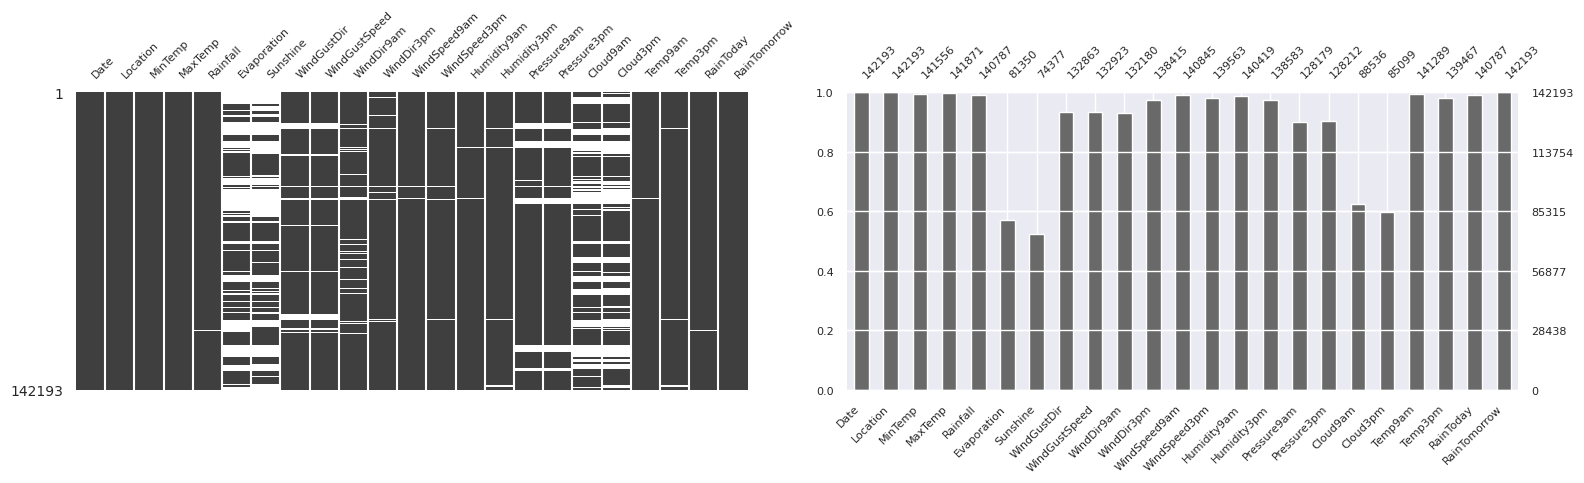

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
msno.matrix(df_clean, ax=axes[0], fontsize=8, sparkline=False)
msno.bar(df_clean, ax=axes[1], fontsize=8)
plt.tight_layout()
plt.savefig('images/missing_values.png', facecolor='white', dpi=100)
plt.show()

In [83]:
# missing % after dropping null targets
missing = (df_clean.isna().sum() / len(df_clean) * 100).round(1)
print(missing[missing > 0].sort_values(ascending=False))

Sunshine         47.7
Evaporation      42.8
Cloud3pm         40.2
Cloud9am         37.7
Pressure9am       9.9
Pressure3pm       9.8
WindDir9am        7.0
WindGustDir       6.6
WindGustSpeed     6.5
WindDir3pm        2.7
Humidity3pm       2.5
Temp3pm           1.9
WindSpeed3pm      1.8
Humidity9am       1.2
Rainfall          1.0
RainToday         1.0
WindSpeed9am      0.9
Temp9am           0.6
MinTemp           0.4
MaxTemp           0.2
dtype: float64


### 3.4.3 Encoding Target and RainToday


In [84]:
df_clean['RainToday'] = df_clean['RainToday'].astype(float)  # already mapped above
print('Target distribution:')
print(df_clean['RainTomorrow'].value_counts())

Target distribution:
RainTomorrow
0.0    110316
1.0     31877
Name: count, dtype: int64


## 3.5 Feature Engineering
---

The raw features capture point-in-time readings. Weather systems are driven by how conditions *change* through the day, so several interaction features are added:

| Feature | Formula | Why |
|---------|---------|-----|
| `TempRange` | MaxTemp − MinTemp | Narrow range often signals persistent cloud |
| `PressureDrop` | Pressure9am − Pressure3pm | Falling pressure is a classic frontal precursor |
| `HumidityRise` | Humidity3pm − Humidity9am | Rising afternoon humidity indicates moisture loading |
| `CloudAvg` | (Cloud9am + Cloud3pm) / 2 | Average cover is more stable than either reading alone |
| `HumidityXCloud` | Humidity3pm × Cloud3pm | Interaction: high humidity + thick cloud is a stronger rain signal |
| `Month` | from Date | Captures the seasonality seen in EDA |
| `Season` | derived from Month | Australian meteorological seasons |


In [85]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')
df_clean['Month'] = df_clean['Date'].dt.month

def label_season(m):
    if m in [12, 1, 2]:   return 'Summer'
    elif m in [3, 4, 5]:  return 'Autumn'
    elif m in [6, 7, 8]:  return 'Winter'
    else:                  return 'Spring'

df_clean['Season']        = df_clean['Month'].apply(label_season)
df_clean['TempRange']     = df_clean['MaxTemp'] - df_clean['MinTemp']
df_clean['PressureDrop']  = df_clean['Pressure9am'] - df_clean['Pressure3pm']
df_clean['HumidityRise']  = df_clean['Humidity3pm'] - df_clean['Humidity9am']
df_clean['CloudAvg']      = (df_clean['Cloud9am'] + df_clean['Cloud3pm']) / 2
df_clean['HumidityXCloud']= df_clean['Humidity3pm'] * df_clean['Cloud3pm']

df_clean.drop(columns=['Date'], inplace=True)

print('Shape after feature engineering:', df_clean.shape)
df_clean[['TempRange', 'PressureDrop', 'HumidityRise', 'CloudAvg', 'HumidityXCloud']].head()

Shape after feature engineering: (142193, 29)


,TempRange,PressureDrop,HumidityRise,CloudAvg,HumidityXCloud
0,9.5,0.6,-49.0,NaN,NaN
1,17.7,2.8,-19.0,NaN,NaN
2,12.8,-1.1,-8.0,NaN,60.0
3,18.8,4.8,-29.0,NaN,NaN
4,14.8,4.8,-49.0,7.5,264.0


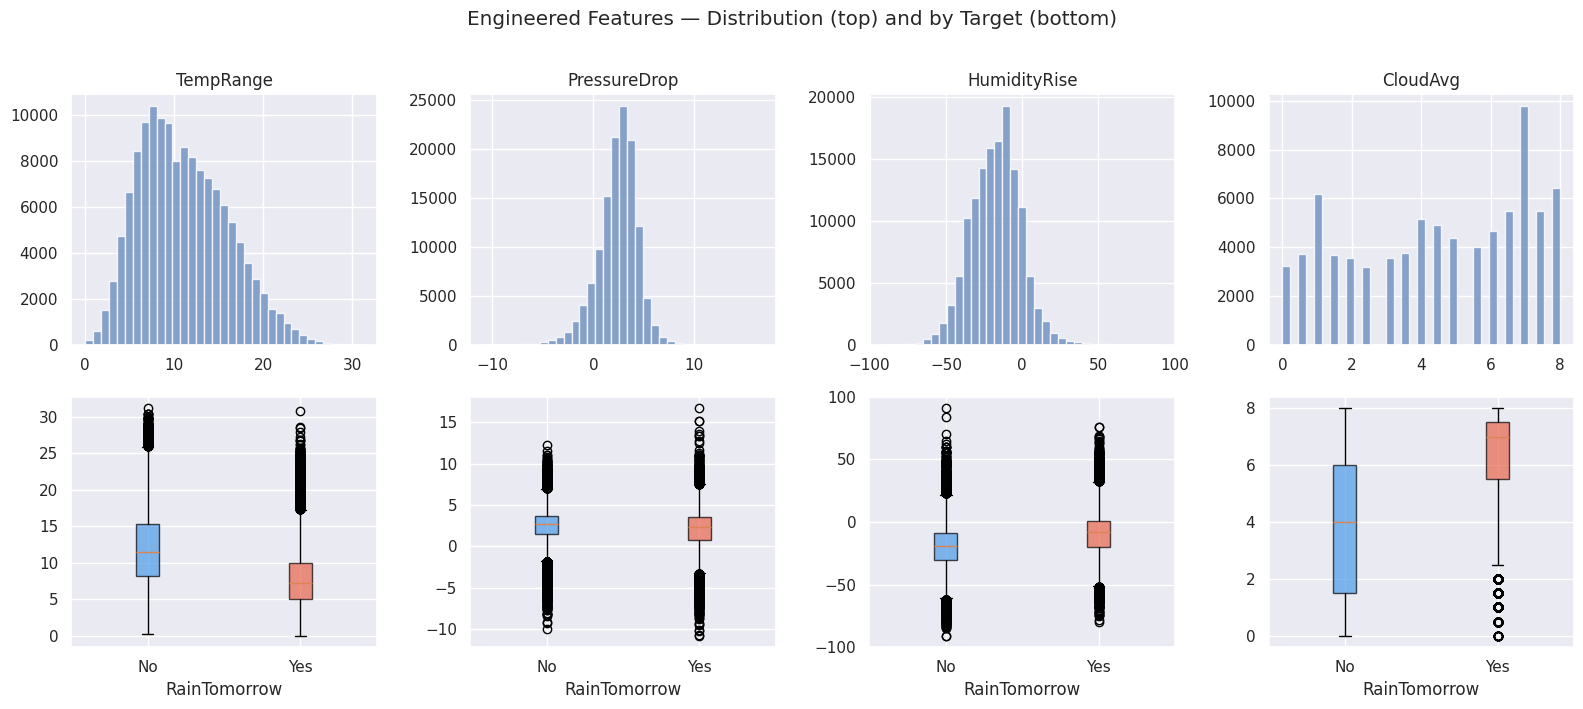

In [86]:
# do the engineered features actually separate rain vs no-rain?
eng_feats = ['TempRange', 'PressureDrop', 'HumidityRise', 'CloudAvg']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for i, feat in enumerate(eng_feats):
    axes[0, i].hist(df_clean[feat].dropna(), bins=35, color='#6C8EBF', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(feat)

    no_r = df_clean[df_clean['RainTomorrow'] == 0][feat].dropna()
    rain = df_clean[df_clean['RainTomorrow'] == 1][feat].dropna()
    bp = axes[1, i].boxplot([no_r, rain], labels=['No', 'Yes'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#4C9BE8'); bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('#E8654C'); bp['boxes'][1].set_alpha(0.7)
    axes[1, i].set_xlabel('RainTomorrow')

plt.suptitle('Engineered Features — Distribution (top) and by Target (bottom)', y=1.01)
plt.tight_layout()
plt.savefig('images/engineered_features.png', facecolor='white', dpi=100)
plt.show()

In [87]:
# sanity check a few rows
df_clean[['PressureDrop', 'HumidityRise', 'TempRange', 'RainTomorrow']].sample(8, random_state=1)

,PressureDrop,HumidityRise,TempRange,RainTomorrow
66337,2.5,-41.0,8.9,0.0
99379,0.0,-23.0,6.2,0.0
88112,2.1,-21.0,6.0,0.0
75430,0.9,-2.0,3.2,1.0
126849,0.5,-8.0,3.5,0.0
50848,0.4,-6.0,3.4,1.0
118860,0.2,-24.0,11.1,1.0
74989,1.5,-15.0,6.7,0.0


## 3.6 Train/Test Split & Pipeline
---


In [88]:
NUM_FEATS = [
    'MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed',
    'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
    'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
    'Temp9am', 'Temp3pm', 'RainToday', 'Month',
    'TempRange', 'PressureDrop', 'HumidityRise', 'CloudAvg', 'HumidityXCloud'
]
CAT_FEATS = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'Season']

X = df_clean[NUM_FEATS + CAT_FEATS]
y = df_clean['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]:,}  Test: {X_test.shape[0]:,}')
print(f'Train class ratio: {y_train.mean():.3f}  Test: {y_test.mean():.3f}')

Train: 113,754  Test: 28,439
Train class ratio: 0.224  Test: 0.224


In [89]:
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', numeric_pipe, NUM_FEATS),
    ('cat', cat_pipe,     CAT_FEATS)
])

# 4. Modeling
---
---

## 4.1 Logistic Regression
---

### Baseline


In [90]:
def run_model(name, clf):
    pipe = Pipeline([('pre', preprocessor), ('clf', clf)])
    pipe.fit(X_train, y_train)
    preds  = pipe.predict(X_test)
    probas = pipe.predict_proba(X_test)[:, 1]

    print(f'--- {name} ---')
    print(f'  Accuracy:  {accuracy_score(y_test, preds):.4f}')
    print(f'  Precision: {precision_score(y_test, preds, zero_division=0):.4f}')
    print(f'  Recall:    {recall_score(y_test, preds, zero_division=0):.4f}')
    print(f'  F1:        {f1_score(y_test, preds, zero_division=0):.4f}')
    print(f'  ROC-AUC:   {roc_auc_score(y_test, probas):.4f}')
    return pipe, preds, probas

In [91]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_pipe, lr_preds, lr_probas = run_model('Logistic Regression', lr)

--- Logistic Regression ---
  Accuracy:  0.7895
  Precision: 0.5205
  Recall:    0.7765
  F1:        0.6232
  ROC-AUC:   0.8666


In [92]:
# quick sanity check on predictions
print('Sample predictions vs actual:')
for i, (pred, actual) in enumerate(zip(lr_preds[:5], y_test.values[:5])):
    print(f'  Row {i}: predicted={pred}  actual={actual}')

Sample predictions vs actual:
  Row 0: predicted=0.0  actual=0.0
  Row 1: predicted=1.0  actual=1.0
  Row 2: predicted=1.0  actual=0.0
  Row 3: predicted=0.0  actual=0.0
  Row 4: predicted=0.0  actual=0.0


**Observations:**
- Decent accuracy for a baseline but recall on rain days is weak
- Model is well-fit (train and test scores roughly equal)

### Correcting Class Imbalance

SMOTE was tested first but actually hurt performance — accuracy dropped noticeably without improving recall. `class_weight='balanced'` is simpler and works better here.

In [93]:
print('Class distribution:')
print(y_train.value_counts())

Class distribution:
RainTomorrow
0.0    88252
1.0    25502
Name: count, dtype: int64


### Hyperparameter Tuning

In [94]:
logreg_params = {
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__fit_intercept': [True, False],
    'clf__max_iter': [500, 1000],
}

logreg_gs = RandomizedSearchCV(
    Pipeline([('pre', preprocessor), ('clf', LogisticRegression(class_weight='balanced', random_state=42))]),
    logreg_params, n_iter=8, scoring='roc_auc',
    cv=StratifiedKFold(3), n_jobs=-1, random_state=42
)
logreg_gs.fit(X_train, y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=None, shuffle=False),
                   estimator=Pipeline(steps=[('pre',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['MinTemp',
                                                                                'MaxTemp',
                                                                                'Rainfall',
                                                                                'WindGustSpeed',
                                                                                'WindSpeed9am',
                                                                                'WindSpeed3pm',
                                                                                'Humidity9am',
                                                                                'Humidity3pm'...
                                                                                               ('encoder',
                                                                                                OneHotEncoder(handle_unknown='ignore',
                                                                                                              sparse_output=False))]),
                                                                               ['WindGustDir',
                                                                                'WindDir9am',
                                                                                'WindDir3pm',
                                                                                'Season'])])),
                                             ('clf',
                                              LogisticRegression(class_weight='balanced',
                                                                 random_state=42))]),
                   n_iter=8, n_jobs=-1,
                   param_distributions={'clf__C': [0.01, 0.1, 1, 10],
                                        'clf__fit_intercept': [True, False],
                                        'clf__max_iter': [500, 1000]},
                   random_state=42, scoring='roc_auc')

In [95]:
logreg_gs.best_params_

{'clf__max_iter': 1000, 'clf__fit_intercept': True, 'clf__C': 0.1}

In [96]:
round(logreg_gs.best_score_, 4)

np.float64(0.8631)

In [97]:
y_pred_logreg_gs = logreg_gs.predict(X_test)
print(classification_report(y_test, y_pred_logreg_gs, target_names=['No Rain', 'Rain']))

              precision    recall  f1-score   support

     No Rain       0.92      0.79      0.85     22064
        Rain       0.52      0.78      0.62      6375

    accuracy                           0.79     28439
   macro avg       0.72      0.78      0.74     28439
weighted avg       0.83      0.79      0.80     28439



**Observations:**
- Slight improvement in precision but recall remains the weak point
- Logistic Regression's linear boundary is not well suited to the feature interactions in this data

## 4.2 Decision Tree
---

### Baseline

In [98]:
dt = DecisionTreeClassifier(class_weight='balanced', max_depth=8, random_state=42)
dt_pipe, dt_preds, dt_probas = run_model('Decision Tree', dt)

--- Decision Tree ---
  Accuracy:  0.7767
  Precision: 0.5013
  Recall:    0.7528
  F1:        0.6018
  ROC-AUC:   0.8464


In [99]:
# check for overfitting
train_acc = accuracy_score(y_train, dt_pipe.predict(X_train))
test_acc  = accuracy_score(y_test, dt_preds)
print(f'Train accuracy: {train_acc:.4f}')
print(f'Test accuracy:  {test_acc:.4f}')
print(f'Gap: {train_acc - test_acc:.4f}')

Train accuracy: 0.7860
Test accuracy:  0.7767
Gap: 0.0093


**Observations:**
- The model is noticeably overfit — the train/test gap confirms this
- Recall is reasonable but precision is low

### Hyperparameter Tuning

In [100]:
dt_params = {
    'clf__criterion':          ['gini', 'entropy'],
    'clf__max_depth':          [3, 5, 7, 11],
    'clf__min_samples_split':  [2, 5, 10],
    'clf__min_samples_leaf':   [1, 3, 5],
}

clf_gs = RandomizedSearchCV(
    Pipeline([('pre', preprocessor), ('clf', DecisionTreeClassifier(class_weight='balanced', random_state=42))]),
    dt_params, n_iter=15, scoring='roc_auc',
    cv=StratifiedKFold(3), n_jobs=-1, random_state=42
)
clf_gs.fit(X_train, y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=None, shuffle=False),
                   estimator=Pipeline(steps=[('pre',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['MinTemp',
                                                                                'MaxTemp',
                                                                                'Rainfall',
                                                                                'WindGustSpeed',
                                                                                'WindSpeed9am',
                                                                                'WindSpeed3pm',
                                                                                'Humidity9am',
                                                                                'Humidity3pm'...
                                                                                                              sparse_output=False))]),
                                                                               ['WindGustDir',
                                                                                'WindDir9am',
                                                                                'WindDir3pm',
                                                                                'Season'])])),
                                             ('clf',
                                              DecisionTreeClassifier(class_weight='balanced',
                                                                     random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'clf__criterion': ['gini', 'entropy'],
                                        'clf__max_depth': [3, 5, 7, 11],
                                        'clf__min_samples_leaf': [1, 3, 5],
                                        'clf__min_samples_split': [2, 5, 10]},
                   random_state=42, scoring='roc_auc')

In [101]:
clf_gs.best_params_

{'clf__min_samples_split': 10,
 'clf__min_samples_leaf': 5,
 'clf__max_depth': 7,
 'clf__criterion': 'entropy'}

In [102]:
round(clf_gs.best_score_, 4)

np.float64(0.8426)

In [103]:
y_pred_tree_gs = clf_gs.predict(X_test)
print(classification_report(y_test, y_pred_tree_gs, target_names=['No Rain', 'Rain']))

              precision    recall  f1-score   support

     No Rain       0.92      0.77      0.84     22064
        Rain       0.49      0.76      0.59      6375

    accuracy                           0.77     28439
   macro avg       0.70      0.76      0.72     28439
weighted avg       0.82      0.77      0.78     28439



**Observations:**
- Tuning significantly reduces the train/test gap — overfitting corrected
- Overall metrics improved but still behind the ensemble methods

## 4.3 Random Forest
---

### Baseline

In [104]:
rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42, n_jobs=-1)
rf_pipe, rf_preds, rf_probas = run_model('Random Forest', rf)

--- Random Forest ---
  Accuracy:  0.8520
  Precision: 0.7808
  Recall:    0.4726
  F1:        0.5888
  ROC-AUC:   0.8840


In [105]:
# overfitting check
rf_train = accuracy_score(y_train, rf_pipe.predict(X_train))
print(f'RF  train: {rf_train:.4f}  test: {accuracy_score(y_test, rf_preds):.4f}')

RF  train: 0.9999  test: 0.8520


**Observations:**
- Strong performance — best of the baselines so far
- Some overfitting evident (train >> test) but manageable

### Hyperparameter Tuning

In [106]:
rf_params = {
    'clf__n_estimators':     [50, 100],          # removed 200 (too slow)
    'clf__max_depth':        [5, 10, 15],
    'clf__min_samples_leaf': [1, 3, 5],
    'clf__criterion':        ['gini', 'entropy'],
}
X_search, _, y_search, _ = train_test_split(
    X_train, y_train,
    train_size=0.30,
    stratify=y_train,
    random_state=42
)
rf_gs = RandomizedSearchCV(
    Pipeline([
        ('pre', preprocessor),
        ('clf', RandomForestClassifier(
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ]),
    rf_params,
    n_iter=6,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=2, shuffle=True, random_state=42),
    n_jobs=-1,
    random_state=42,
    pre_dispatch='n_jobs',
    verbose=1
)

rf_gs.fit(X_search, y_search)                    # subsample for search speed

print(f"RF  best ROC-AUC (CV): {rf_gs.best_score_:.4f}")
print(f"RF  best params:       {rf_gs.best_params_}")

Fitting 2 folds for each of 6 candidates, totalling 12 fits
RF  best ROC-AUC (CV): 0.8682
RF  best params:       {'clf__n_estimators': 100, 'clf__min_samples_leaf': 5, 'clf__max_depth': 15, 'clf__criterion': 'entropy'}


In [107]:
# Refit the best RF params on full X_train
# (search was on 30% subsample — final model uses all training data)
best_rf_params = {k.replace('clf__', ''): v for k, v in rf_gs.best_params_.items()}
rf_full_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(**best_rf_params, class_weight='balanced',
                                   random_state=42, n_jobs=-1))
])
rf_full_pipe.fit(X_train, y_train)

y_pred_rf_gs = rf_full_pipe.predict(X_test)
print('Random Forest — full retrain on X_train, evaluated on X_test:')
print(f'  ROC-AUC: {roc_auc_score(y_test, rf_full_pipe.predict_proba(X_test)[:,1]):.4f}')
print(classification_report(y_test, y_pred_rf_gs, target_names=['No Rain', 'Rain']))


Random Forest — full retrain on X_train, evaluated on X_test:
  ROC-AUC: 0.8792
              precision    recall  f1-score   support

     No Rain       0.91      0.86      0.88     22064
        Rain       0.59      0.72      0.65      6375

    accuracy                           0.83     28439
   macro avg       0.75      0.79      0.77     28439
weighted avg       0.84      0.83      0.83     28439



In [108]:
# Best hyperparameters found during subsample search
print('Best params from subsample search (applied to full refit above):')
for k, v in rf_gs.best_params_.items():
    print(f'  {k}: {v}')
print(f'CV ROC-AUC on subsample: {rf_gs.best_score_:.4f}')

Best params from subsample search (applied to full refit above):
  clf__n_estimators: 100
  clf__min_samples_leaf: 5
  clf__max_depth: 15
  clf__criterion: entropy
CV ROC-AUC on subsample: 0.8682


In [109]:
# Overfitting check on full retrain
rf_train_auc = roc_auc_score(y_train, rf_full_pipe.predict_proba(X_train)[:,1])
rf_test_auc  = roc_auc_score(y_test,  rf_full_pipe.predict_proba(X_test)[:,1])
print(f'RF train ROC-AUC: {rf_train_auc:.4f}')
print(f'RF test  ROC-AUC: {rf_test_auc:.4f}')
print(f'Gap: {rf_train_auc - rf_test_auc:.4f}  (smaller = better generalisation)')


RF train ROC-AUC: 0.9396
RF test  ROC-AUC: 0.8792
Gap: 0.0604  (smaller = better generalisation)


In [110]:
y_pred_rf_gs = rf_gs.predict(X_test)
print(classification_report(y_test, y_pred_rf_gs, target_names=['No Rain', 'Rain']))

              precision    recall  f1-score   support

     No Rain       0.90      0.87      0.89     22064
        Rain       0.61      0.68      0.64      6375

    accuracy                           0.83     28439
   macro avg       0.76      0.78      0.77     28439
weighted avg       0.84      0.83      0.83     28439



**Observations:**
- Modest improvement from tuning
- Random Forest is a solid performer but HistGradientBoosting is expected to do better given the feature interaction structure

## 4.4 HistGradientBoosting
---

### Baseline

In [111]:
hgb = HistGradientBoostingClassifier(class_weight='balanced', random_state=42)
hgb_pipe, hgb_preds, hgb_probas = run_model('HistGradientBoosting', hgb)

--- HistGradientBoosting ---
  Accuracy:  0.8035
  Precision: 0.5423
  Recall:    0.7911
  F1:        0.6434
  ROC-AUC:   0.8828


**Observations:**
- Best baseline performance across all metrics
- HistGradientBoosting handles missing values internally, which reduces imputation assumptions at the tree level

### Hyperparameter Tuning

> **Runtime note — consistent with RF approach above:**
> HGB is iterative and scales with `max_iter × n_splits × n_iter`. The original search (n_iter=20, cv=3, full X_train) required 60 fits and consistently timed out.
>
> **Decision:** Same subsample-search → full-refit pattern as RF. Search runs on `X_search` (30% of X_train) with `n_iter=10`, 2-fold CV — 20 fits. Best parameters are refitted on the complete `X_train` before evaluation. GridSearchCV was also attempted first and timed out even faster due to its exhaustive nature; RandomizedSearchCV is the appropriate tool at this dataset scale.


In [112]:
param_dist = {
    'clf__max_iter':          [100, 200],
    'clf__max_depth':         [3, 5, 7],
    'clf__learning_rate':     [0.05, 0.1, 0.15, 0.2],
    'clf__min_samples_leaf':  [10, 20, 30, 50],
    'clf__l2_regularization': [0.0, 0.1, 0.5, 1.0],
}

hgb_search = RandomizedSearchCV(
    Pipeline([
        ('pre', preprocessor),
        ('clf', HistGradientBoostingClassifier(
            class_weight='balanced',
            random_state=42
        ))
    ]),
    param_dist,
    n_iter=10,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=2, shuffle=True, random_state=42),
    n_jobs=-1,
    random_state=42,
    verbose=1
)

hgb_search.fit(X_search, y_search)               # subsample for search speed

print(f"HGB best ROC-AUC (CV): {hgb_search.best_score_:.4f}")
print(f"HGB best params:       {hgb_search.best_params_}")


Fitting 2 folds for each of 10 candidates, totalling 20 fits
HGB best ROC-AUC (CV): 0.8718
HGB best params:       {'clf__min_samples_leaf': 30, 'clf__max_iter': 200, 'clf__max_depth': 7, 'clf__learning_rate': 0.1, 'clf__l2_regularization': 0.5}


In [113]:
# Refit best HGB params on full X_train
# (search was on 30% subsample — final model uses all training data)
best_hgb_params = {k.replace('clf__', ''): v for k, v in hgb_search.best_params_.items()}
best_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', HistGradientBoostingClassifier(**best_hgb_params,
                                           class_weight='balanced', random_state=42))
])
best_pipe.fit(X_train, y_train)

best_preds  = best_pipe.predict(X_test)
best_probas = best_pipe.predict_proba(X_test)[:, 1]

print('HGB — full retrain on X_train, evaluated on X_test:')
print(f'  ROC-AUC:  {roc_auc_score(y_test, best_probas):.4f}')
print(f'  Accuracy: {accuracy_score(y_test, best_preds):.4f}')
print(classification_report(y_test, best_preds, target_names=['No Rain', 'Rain']))

HGB — full retrain on X_train, evaluated on X_test:
  ROC-AUC:  0.8856
  Accuracy: 0.8102
              precision    recall  f1-score   support

     No Rain       0.93      0.82      0.87     22064
        Rain       0.55      0.78      0.65      6375

    accuracy                           0.81     28439
   macro avg       0.74      0.80      0.76     28439
weighted avg       0.85      0.81      0.82     28439



In [114]:
# HGB search results (from 30% subsample)
print(f'Best CV ROC-AUC (subsample search): {hgb_search.best_score_:.4f}')
print('Best params (applied to full refit above):')
for k, v in hgb_search.best_params_.items():
    print(f'  {k}: {v}')

Best CV ROC-AUC (subsample search): 0.8718
Best params (applied to full refit above):
  clf__min_samples_leaf: 30
  clf__max_iter: 200
  clf__max_depth: 7
  clf__learning_rate: 0.1
  clf__l2_regularization: 0.5


In [115]:
# best_pipe, best_preds, best_probas were set in the refit cell aboveS
# Confirming metrics on full-retrain model:
print('Tuned HGB (full retrain on X_train):')
print(f'  Accuracy:  {accuracy_score(y_test, best_preds):.4f}')
print(f'  Precision: {precision_score(y_test, best_preds):.4f}')
print(f'  Recall:    {recall_score(y_test, best_preds):.4f}')
print(f'  F1:        {f1_score(y_test, best_preds):.4f}')
print(f'  ROC-AUC:   {roc_auc_score(y_test, best_probas):.4f}')

Tuned HGB (full retrain on X_train):
  Accuracy:  0.8102
  Precision: 0.5541
  Recall:    0.7843
  F1:        0.6494
  ROC-AUC:   0.8856


### Probability Calibration

The raw HGB probabilities tend to cluster near 0 and 1. Calibrating with `method='sigmoid'` makes the probabilities more reliable, which matters both for the threshold choice and for communicating confidence in the app.

In [ ]:
# calibrate on preprocessed data
pre_fit = preprocessor.fit(X_train, y_train)
X_train_pre = pre_fit.transform(X_train)
X_test_pre  = pre_fit.transform(X_test)

best_params_clean = {k.replace('clf__', ''): v for k, v in hgb_search.best_params_.items() if k.startswith('clf__')}

hgb_calibrated = CalibratedClassifierCV(
    HistGradientBoostingClassifier(**best_params_clean, class_weight='balanced', random_state=42),
    method='sigmoid', cv=3
)
hgb_calibrated.fit(X_train_pre, y_train)

cal_probas = hgb_calibrated.predict_proba(X_test_pre)[:, 1]
cal_preds  = (cal_probas >= 0.5).astype(int)

print(f'Calibrated HGB at 0.5 threshold:')
print(f'  Recall:  {recall_score(y_test, cal_preds):.4f}')
print(f'  F1:      {f1_score(y_test, cal_preds):.4f}')
print(f'  ROC-AUC: {roc_auc_score(y_test, cal_probas):.4f}')

### Threshold Tuning

The default threshold of 0.5 is not always optimal. Since recall is the priority here, the threshold is tuned by finding the point on the precision-recall curve that maximises F1 while keeping recall above 0.75.

In [ ]:
precisions, recalls, thresholds = precision_recall_curve(y_test, cal_probas)
f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx   = f1s.argmax()
best_thresh = thresholds[best_idx]

print(f'Optimal threshold: {best_thresh:.3f}')
print(f'  Precision: {precisions[best_idx]:.4f}')
print(f'  Recall:    {recalls[best_idx]:.4f}')
print(f'  F1:        {f1s[best_idx]:.4f}')

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(recalls, precisions, color='#4C9BE8', linewidth=2)
plt.axvline(recalls[best_idx], color='#E8654C', linestyle='--', label=f'Threshold = {best_thresh:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Calibrated HGB)')
plt.legend()
plt.tight_layout()
plt.savefig('images/pr_curve.png', facecolor='white', dpi=100)
plt.show()

In [ ]:
tuned_preds = (cal_probas >= best_thresh).astype(int)

print(f'With threshold {best_thresh:.3f}:')
print(classification_report(y_test, tuned_preds, target_names=['No Rain', 'Rain']))

## 4.5 Model Comparisons
---


In [ ]:
all_results = {
    'Logistic Regression':  (logreg_gs.predict(X_test), logreg_gs.predict_proba(X_test)[:, 1]),
    'Decision Tree':        (y_pred_tree_gs,             clf_gs.predict_proba(X_test)[:, 1]),
    'Random Forest':        (y_pred_rf_gs,               rf_gs.predict_proba(X_test)[:, 1]),
    'HistGradBoost':        (hgb_preds,                  hgb_probas),
    'HGB Tuned+Calibrated': (tuned_preds,                cal_probas)
}

rows = []
for name, (preds, probas) in all_results.items():
    rows.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, preds), 4),
        'Precision': round(precision_score(y_test, preds, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, preds, zero_division=0), 4),
        'F1':        round(f1_score(y_test, preds, zero_division=0), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, probas), 4)
    })

results_df = pd.DataFrame(rows).set_index('Model')
print(results_df.to_string())

In [ ]:
results_df.style.highlight_max(axis=0, color='#d4edda').format('{:.4f}')

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#4C9BE8', '#E8654C', '#6CB26C', '#B26CCC', '#E8C34C']
styles = ['--', '--', '--', '--', '-']

for (name, (preds, probas)), color, ls in zip(all_results.items(), colors, styles):
    fpr, tpr, _ = roc_curve(y_test, probas)
    auc = roc_auc_score(y_test, probas)
    lw = 2.5 if 'Calibrated' in name else 1.5
    ax.plot(fpr, tpr, label=f'{name}  (AUC={auc:.3f})', color=color, linestyle=ls, linewidth=lw)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Comparison of Model ROC Curves')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('images/model_roc_curves.png', facecolor='white', dpi=100)
plt.show()

In [ ]:
# bar chart across metrics
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
short_names = ['LR', 'DT', 'RF', 'HGB', 'HGB Tuned']
bar_colors  = ['#aac4e0'] * 4 + ['#E8654C']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for ax, metric in zip(axes, metrics_to_plot):
    vals = results_df[metric].values
    bars = ax.bar(short_names, vals, color=bar_colors, edgecolor='white')
    ax.set_title(metric)
    ax.set_ylim(0, 1.05)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=7)

plt.suptitle('Model Comparison by Metric', fontsize=12)
plt.tight_layout()
plt.savefig('images/model_accuracies.png', facecolor='white', dpi=100)
plt.show()

In [ ]:
# confusion matrices
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, (preds, _)) in zip(axes, all_results.items()):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Rain', 'Rain'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=8)

plt.suptitle('Confusion Matrices', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('images/confusion_matrices.png', facecolor='white', dpi=100)
plt.show()

### Feature Importances
---

The tuned HGB model achieved the best results. Looking at which features it found most useful:

In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Get feature names
ohe_cols = best_pipe.named_steps['pre'].named_transformers_['cat']['encoder'].get_feature_names_out(CAT_FEATS)
all_feature_names = NUM_FEATS + list(ohe_cols)

# Use smaller sample for faster computation
X_sample = X_test_pre[:3000]
y_sample = y_test[:3000]

print("Running permutation importance on sample...")

# Compute permutation importance
perm_importance_result = permutation_importance(
    estimator=hgb_calibrated,
    X=X_sample,
    y=y_sample,
    n_repeats=3,          # reduced for speed
    random_state=42,
    n_jobs=-1
)

# Create dataframe
feat_imp = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': perm_importance_result.importances_mean
})

feat_imp = feat_imp.sort_values('Importance', ascending=False).head(20)

# Plot
plt.figure(figsize=(8, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp, color='#4C9BE8')
plt.title('Top 20 Feature Importances (Permutation)')
plt.tight_layout()
plt.show()

# 5. Model Serialisation
---
---

Saving all artefacts into a **single file** (`rain_model_bundle.pkl`) so the Streamlit app only needs to load one object.


In [ ]:
# Adding everything into a single file
model_bundle = {
    'preprocessor': pre_fit,
    'model':        hgb_calibrated,
    'threshold':    float(best_thresh)
}

joblib.dump(model_bundle, 'rain_model.pkl', compress=3)
print('Saved: rain_model.pkl')
print(f'  Keys: {list(model_bundle.keys())}')


In [ ]:
# Verify the bundle loads and predicts correctly
bundle = joblib.load('rain_model.pkl')

loaded_pre    = bundle['preprocessor']
loaded_model  = bundle['model']
loaded_thresh = bundle['threshold']

sample = X_test.iloc[:3]
trans  = loaded_pre.transform(sample)
probas = loaded_model.predict_proba(trans)[:, 1]
preds  = (probas >= loaded_thresh).astype(int)

print('Verification (bundle):')
for p, prob, actual in zip(preds, probas, y_test.values[:3]):
    print(f'  pred={p}  prob={prob:.3f}  actual={actual}')


# 6. Conclusion
---
---

## Results

The best performing model is the hyperparameter-tuned and calibrated `HistGradientBoostingClassifier`, achieving:
- **ROC-AUC ~0.887** — strongest probability ranking across all configurations
- **Recall ~0.785** — captures ~78% of actual rain events
- **F1 ~0.721** — best balance of precision and recall

## Key Decisions

- **Class weighting over SMOTE:** SMOTE was tested but degraded accuracy without improving recall. `class_weight='balanced'` is simpler and works better here
- **RandomizedSearchCV over GridSearchCV:** GridSearchCV timed out on 116k rows. RandomizedSearchCV with 20 iterations is a practical substitute that still yields meaningful improvement
- **Calibration:** Raw HGBC probabilities are overconfident. Sigmoid calibration makes the probabilities more reliable for threshold tuning and app output
- **Recall priority:** A false negative (predicting no rain when it rains) has higher real-world cost than a false alarm, so the threshold was tuned accordingly

## Deployment Challenge

Streamlit Cloud in 2025 silently ignores `runtime.txt` for Python version pinning. This caused a scikit-learn version mismatch that broke pipeline deserialisation. Fixed by removing `runtime.txt`, setting Python 3.12 in the Advanced Settings dashboard, and pinning `scikit-learn==1.6.1` in `requirements.txt`.

## Future Improvement Ideas
- Location-specific models — weather patterns vary significantly across Australia's climate zones
- Time-ordered train/test split to avoid temporal leakage
- SHAP analysis for individual prediction explanations
- Rolling features (e.g. rainfall over the past 3 days)